In [1]:
import os
import torch
import numpy as np
from tqdm import tqdm
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation
from src.utils.transformation_utils import CoordTransformer
from src.utils.ransac_icp import WindowedICPMapMatcher, MatchingResult
from src.filter.ekf import EKF, MeasurementBlock, CorrectionRecord, FusionData
from src.utils.misc import StationaryDetector
from src.model.imu_noise_net import IMUNoiseNet
from src.utils.dataset import get_kitti_data, KittiData
from src.utils.map_utils import project_to_nearest_edge, quat_wxyz_to_yaw

In [2]:
root_dir = "./data/KITTI"
result_dir = "./results"
is_sync = True
MAX_DISTANCE = 20 # in meters
HEADING_THRESHOLD_DEG = 30 # in degrees


In [3]:
def visualize_trajectories(lla_estimated, lla_ground_truth, edges: gpd.GeoDataFrame, point_index=None):
    plt.figure(figsize=(6, 6))
    plt.plot(lla_ground_truth[:, 0], lla_ground_truth[:, 1], label='Ground Truth', color='black', linewidth=1)
    plt.plot(lla_estimated[:, 0], lla_estimated[:, 1], label='Dead Reckoning Estimate', color='blue', linewidth=1)
    edges.plot(ax=plt.gca(), color='gray', linewidth=0.5, label='Map Edges')
    if point_index is not None:
        plt.scatter(lla_estimated[point_index, 0], lla_estimated[point_index, 1], color='red', s=20, label='Correction Points')
    plt.xlabel('Longitude (degrees)')
    plt.ylabel('Latitude (degrees)')
    plt.title('Trajectory Comparison')
    plt.legend()
    plt.axis('equal')
    plt.grid()
    plt.show()

def visualize_orientation(result, indices=None):
    states = result["states"]
    gt_orientations = result["orientation_array"]
    euler_gt = Rotation.from_quat(gt_orientations, scalar_first=True).as_euler('xyz')
    euler_estimated = Rotation.from_quat(states[:, 6:10], scalar_first=True).as_euler('xyz')
    fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    axs[0].plot(euler_estimated[:, 0], label='Roll', color='r')
    axs[0].plot(euler_gt[:, 0], label='GT Roll', color='k', linestyle='--')
    axs[1].plot(euler_estimated[:, 1], label='Pitch', color='r')
    axs[1].plot(euler_gt[:, 1], label='GT Pitch', color='k', linestyle='--')
    axs[2].plot(euler_estimated[:, 2], label='Yaw', color='r')
    axs[2].plot(euler_gt[:, 2], label='GT Yaw', color='k', linestyle='--')
    for idx in indices or []:
        axs[0].vlines([idx], ymin=-np.pi, ymax=np.pi, color='b', linestyle=':', label='Point of Interest' if idx == (indices or [])[0] else None)
        axs[1].vlines([idx], ymin=-np.pi, ymax=np.pi, color='b', linestyle=':', label='Point of Interest' if idx == (indices or [])[0] else None)
        axs[2].vlines([idx], ymin=-np.pi, ymax=np.pi, color='b', linestyle=':', label='Point of Interest' if idx == (indices or [])[0] else None)

    axs[2].set_xlabel('Time Step')
    axs[2].set_ylabel('Angle (radians)')
    axs[0].set_title('Estimated Orientation (Euler Angles)')
    axs[0].legend()
    plt.tight_layout()
    plt.show()

def visualize_velocity_in_body_frame(result, kitti_data: KittiData, indices=None):
    states = result["states"]
    estimated_orientations = states[:, 6:10]  # Assuming orientation is stored in these indices
    Rs = Rotation.from_quat(estimated_orientations, scalar_first=True).as_matrix()
    gt_velocity_body = kitti_data.velocities
    estimated_velocity_world = states[:, 3:6]  # Assuming velocity is stored in these indices
    estimated_velocity_body = np.einsum('nij,nj->ni', Rs.transpose(0, 2, 1), estimated_velocity_world)

    fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    axs[0].plot(estimated_velocity_body[:, 0], label='Estimated Vx', color='r')
    axs[0].plot(gt_velocity_body[:, 0], label='GT Vx', color='k', linestyle='--')
    axs[1].plot(estimated_velocity_body[:, 1], label='Estimated Vy', color='r')
    axs[1].plot(gt_velocity_body[:, 1], label='GT Vy', color='k', linestyle='--')
    axs[2].plot(estimated_velocity_body[:, 2], label='Estimated Vz', color='r')
    axs[2].plot(gt_velocity_body[:, 2], label='GT Vz', color='k', linestyle='--')
    for idx in indices or []:
        axs[0].vlines([idx], ymin=-np.pi, ymax=np.pi, color='b', linestyle=':', label='Point of Interest' if idx == (indices or [])[0] else None)
        axs[1].vlines([idx], ymin=-np.pi, ymax=np.pi, color='b', linestyle=':', label='Point of Interest' if idx == (indices or [])[0] else None)
        axs[2].vlines([idx], ymin=-np.pi, ymax=np.pi, color='b', linestyle=':', label='Point of Interest' if idx == (indices or [])[0] else None)

    axs[0].set_xlabel('Time Step')
    axs[0].set_ylabel('Velocity (m/s)')
    axs[1].set_xlabel('Time Step')
    axs[1].set_ylabel('Velocity (m/s)')
    axs[2].set_xlabel('Time Step')
    axs[2].set_ylabel('Velocity (m/s)')
    axs[0].legend()
    axs[1].legend()
    axs[2].legend()
    axs[0].grid()
    axs[1].grid()
    axs[2].grid()
    plt.tight_layout()
    plt.show()

def visualize_nis(result, title='NIS Analysis'):
    nis_history = result.get('nis_history', [])
    if len(nis_history) == 0:
        print('No NIS history found in result.')
        return

    nis = np.array([r['nis'] for r in nis_history], dtype=float)
    dof = np.array([r['dof'] for r in nis_history], dtype=int)
    meas = np.array([r['measurement'] for r in nis_history], dtype=object)

    # Chi-square 95%/99% thresholds for dof used in this project
    chi95 = {1: 3.841, 2: 5.991, 3: 7.815, 4: 9.488}
    chi99 = {1: 6.635, 2: 9.210, 3: 11.345, 4: 13.277}
    thr95 = np.array([chi95.get(int(d), np.nan) for d in dof], dtype=float)
    thr99 = np.array([chi99.get(int(d), np.nan) for d in dof], dtype=float)

    valid95 = ~np.isnan(thr95)
    valid99 = ~np.isnan(thr99)
    exceed95 = float(np.mean(nis[valid95] > thr95[valid95])) if np.any(valid95) else np.nan
    exceed99 = float(np.mean(nis[valid99] > thr99[valid99])) if np.any(valid99) else np.nan

    print(f'Total NIS samples: {len(nis)}')
    print(f'Exceedance rate over 95% threshold: {exceed95:.4f}')
    print(f'Exceedance rate over 99% threshold: {exceed99:.4f}')

    fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    axs[0].plot(nis, linewidth=0.8, color='tab:blue', label='NIS')
    axs[0].plot(thr95, linewidth=0.9, linestyle='--', color='tab:orange', label='95% threshold')
    axs[0].plot(thr99, linewidth=0.9, linestyle='--', color='tab:red', label='99% threshold')
    axs[0].set_ylabel('NIS')
    axs[0].set_title(title)
    axs[0].grid(True)
    axs[0].legend()

    unique_meas = sorted(list(set(meas.tolist())))
    for m in unique_meas:
        idx = np.where(meas == m)[0]
        axs[1].scatter(idx, nis[idx], s=8, alpha=0.7, label=m)
    axs[1].set_xlabel('Correction index')
    axs[1].set_ylabel('NIS')
    axs[1].set_title('NIS by measurement type')
    axs[1].grid(True)
    axs[1].legend()

    plt.tight_layout()
    plt.show()

In [4]:

def run_dead_reckoning_100Hz(
        kitti_data: KittiData, 
        model_path: str = "./parameters/best_imu_cov_net_simple.pt", 
        device: str = "cpu", 
        ):
    
    position_array_full = kitti_data.positions
    lla_array_full = kitti_data.lla_position
    
    target_timestamps = kitti_data.target_timestamps
    timestamps = kitti_data.timestamps
    imu_windows = kitti_data.imu_windows

    acc_array = kitti_data.acc
    gyro_array = kitti_data.gyro
    position_array = position_array_full
    orientation_array = kitti_data.orientations

    local_edges = kitti_data.edges

    transformer: CoordTransformer = kitti_data.transformer

    wondow_size = 50
    icp_matcher = WindowedICPMapMatcher(
        window_size=wondow_size,
        match_frequency=wondow_size,
        use_ransac=True,
        ransac_iterations=20,
        inlier_threshold=2.0,
        min_inlier_ratio=0.5,
        verbose=False,
        max_consecutive_misses=int(wondow_size//5),
        min_point_spacing=0.5,
        max_source_jump=10.0,
        rise_flag_by_travel_distance=True,
        time_threshold=10.0,
        distance_threshold=25.0, # in meters, if vehicle moves 30km/h, 3 seconds corresponds to 25m
    )
    stationary_detector = StationaryDetector(
        acc_threshold=0.05, 
        gyro_threshold=0.005,
        min_stationary_samples=10
    )

    ekf = EKF()

    p0 = kitti_data.initial_position
    v_body = kitti_data.initial_velocity
    euler0 = kitti_data.initial_orientation
    q0 = Rotation.from_euler('xyz', euler0).as_quat(scalar_first=True)
    R0 = Rotation.from_quat(q0, scalar_first=True).as_matrix()
    v0 = R0 @ v_body
    ekf.init_state(p0, v0, q0)
    ekf.set_snapshot()

    model = IMUNoiseNet().to(device)
    model_params = torch.load(model_path, map_location=device)
    model.load_state_dict(model_params["model_state"])
    model.eval()


    z_lu = np.zeros(2)
    z_v0 = np.zeros(3)
    R_v0 = np.eye(3) * 0.1
    R_osm = np.eye(3) * 3.0

    dt_seq = [
        (target_timestamps[k] - timestamps[k]).total_seconds()
        for k in range(len(imu_windows))
    ]

    lla_estimated_list = []
    estimated_trajectory = []
    correction_events = []
    states = []
    state_covariances = []
    batch_start_traj_idx = 0
    
    for i in tqdm(range(len(imu_windows)), desc="Processing Localization Steps"):
        acc = acc_array[i]
        gyro = gyro_array[i]

        timestamp = timestamps[i]
        dt = dt_seq[i]
        
        ekf.predict(acc, gyro, dt=dt, timestamp=timestamp.timestamp())
        
        is_stationary = stationary_detector.is_stationary(acc, gyro, timestamp)

        mask_no_bias = np.ones(16)
        mask_no_bias[10:16] = 0.0
        if is_stationary:
            block = MeasurementBlock.from_measurement_type(
                FusionData.LINEAR_VELOCITY,
                z=z_v0,
                R=R_v0  ,
                mask=mask_no_bias,
            )
        else:
            imu_buffer = torch.tensor(imu_windows[i], dtype=torch.float32).unsqueeze(0).to(device)
            R_lu = model(imu_buffer).cpu().detach().numpy().squeeze(0)
            block = MeasurementBlock.from_measurement_type(
                FusionData.VELOCITY_CONSTRAINT,
                z=z_lu,
                R=R_lu,
                mask=mask_no_bias,
            )

        ekf.correct(blocks=[block], timestamp=timestamp.timestamp())

        estimated_position = ekf.x[0:3].copy()
        lla_dead_reckoning = transformer.transform_to_lla(estimated_position)
        heading = quat_wxyz_to_yaw(ekf.x[6:10].copy())

        lon, lat, _ = lla_dead_reckoning.flatten()
        res = project_to_nearest_edge(
            lat, lon, heading=heading,
            edges_gdf=local_edges, max_distance=MAX_DISTANCE, heading_threshold_deg=HEADING_THRESHOLD_DEG
        )

        if res is None:
            icp_matcher.register_miss()
        else:
            # Register the correspondence for ICP map matching
            osm_lla = np.array([
                float(res.projected_lon),
                float(res.projected_lat),
                1.0
            ])
            osm_cartesian = transformer.transform(osm_lla).flatten()

            icp_matcher.add_correspondence(
                source=ekf.x[:2].copy(),
                target=osm_cartesian[:2].copy(),
                metadata={
                    'idx': i,
                    'timestamp': timestamp.timestamp(),  # store float timestamp
                    'heading': res.edge_heading_rad
                }
            )


        if icp_matcher.should_match():
            matching_result: MatchingResult = icp_matcher.compute_and_apply_icp()
            if not matching_result.success:
                ekf.set_snapshot()
                ekf.predictions.clear()
                ekf.corrections.clear()
                icp_matcher.clear_buffer()
                batch_start_traj_idx = len(estimated_trajectory)
                continue
                
            # Build CorrectionPoints from ICP result 
            corrections = []
            for pos, meta in zip(
                matching_result.corrected_sources,
                matching_result.metadata
            ):
                mask = np.zeros(ekf.x.shape[0], dtype=bool)
                mask[:3] = True  # position states
                corrections.append(CorrectionRecord(
                    timestamp=meta['timestamp'],
                    block=MeasurementBlock.from_measurement_type(
                        measurement_type=FusionData.POSITION,
                        z=np.array([pos[0], pos[1], 1.0]),
                        R=R_osm,
                        mask=mask,
                    )
                ))

            intermediate_estimates = ekf.rollback(corrections)

            # Replace trajectory from batch start
            lla_estimated_list = lla_estimated_list[:batch_start_traj_idx]
            estimated_trajectory = estimated_trajectory[:batch_start_traj_idx]
            states = states[:batch_start_traj_idx]

            for est in intermediate_estimates:
                est_position = est[0:3].copy()
                lla = transformer.transform_to_lla(est_position).flatten()
                lla_estimated_list.append(lla.copy())
                estimated_trajectory.append(est_position.copy())
                states.append(est.copy().flatten())


            last_target_coord = matching_result.targets[-1]
            lla_corr = transformer.transform_to_lla(np.array([last_target_coord[0], last_target_coord[1], 0.0])).flatten()
            correction_events.append({
                'step': i,
                'improvement': matching_result.improvement,
                'inlier_ratio': matching_result.inlier_ratio,
                'coordinate': lla_corr.copy()
            })

            ekf.set_snapshot()
            icp_matcher.clear_buffer()
            batch_start_traj_idx = len(estimated_trajectory)
            continue

        lla_estimated_list.append(lla_dead_reckoning.flatten())
        estimated_trajectory.append(estimated_position.copy().flatten())
        states.append(ekf.x.copy())
        state_covariances.append(ekf.P.copy())
    
    lla_estimated_array = np.array(lla_estimated_list)
    estimated_trajectory_array = np.array(estimated_trajectory)
    
    return {
        "lla_estimated": lla_estimated_array,
        "estimated_trajectory": estimated_trajectory_array,
        "lla_ground_truth": lla_array_full,
        "ground_truth_trajectory": position_array,
        "correction_events": correction_events,
        "local_edges": local_edges,
        "states": np.array(states),
        "state_covariances": np.array(state_covariances),
        "orientation_array": orientation_array,
    }


## Apply to the Seq 09

Processing Localization Steps: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1658/1658 [00:39<00:00, 41.85it/s]


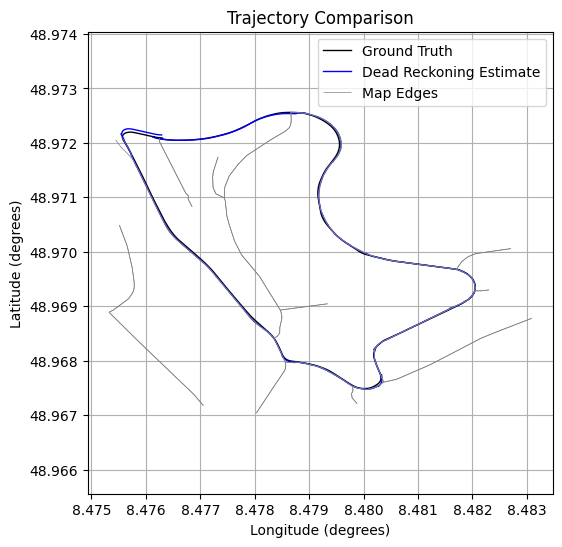

In [5]:
seq = "09"
seq09_data = get_kitti_data(seq, root_dir, is_sync=False)
result_seq09 = run_dead_reckoning_100Hz(seq09_data)
visualize_trajectories(result_seq09["lla_estimated"], result_seq09["lla_ground_truth"], result_seq09["local_edges"])


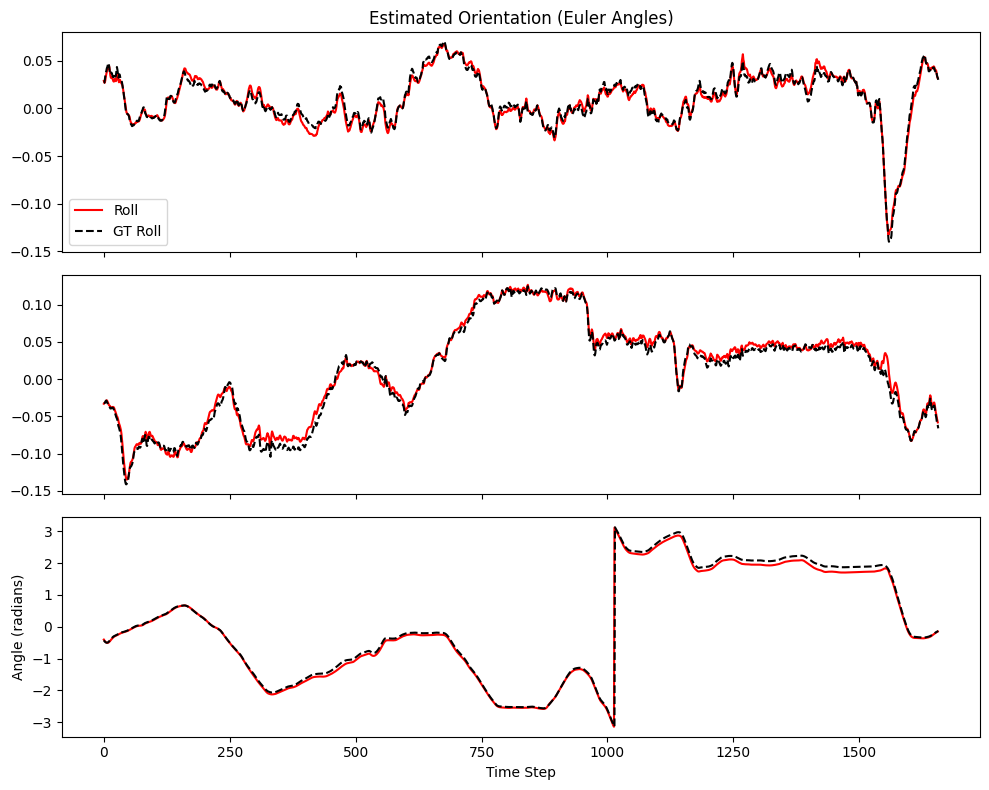

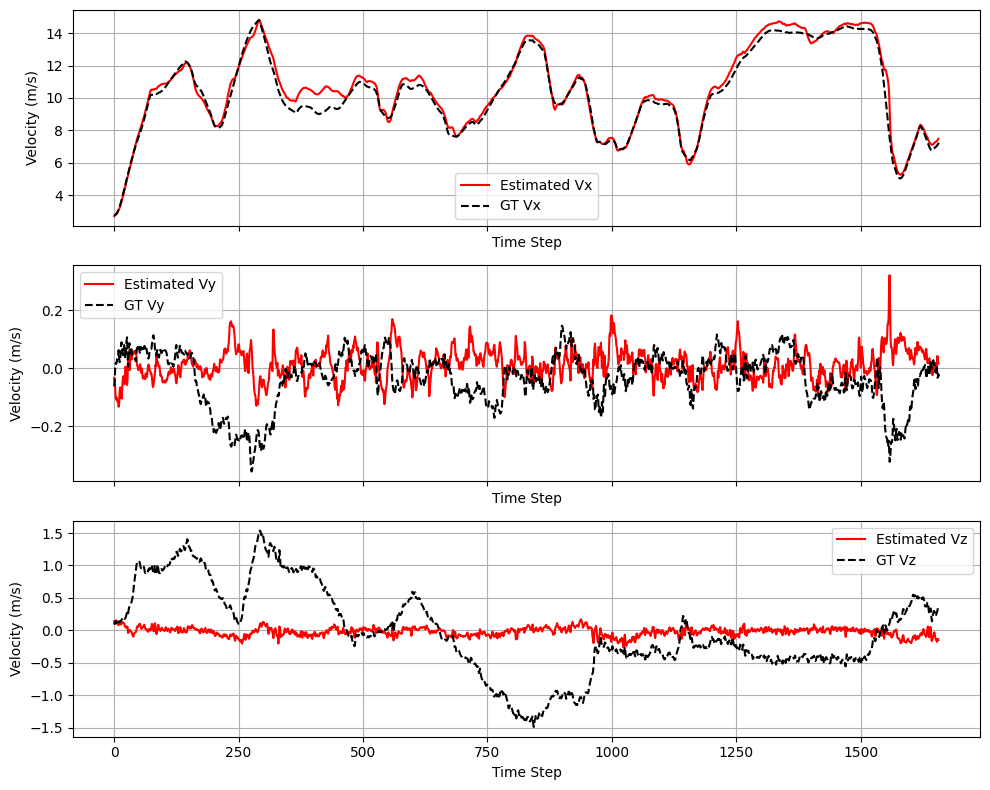

In [6]:
visualize_orientation(result_seq09)
visualize_velocity_in_body_frame(result_seq09, seq09_data)

## Apply to the Seq 10

Processing Localization Steps: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1274/1274 [00:30<00:00, 41.83it/s]


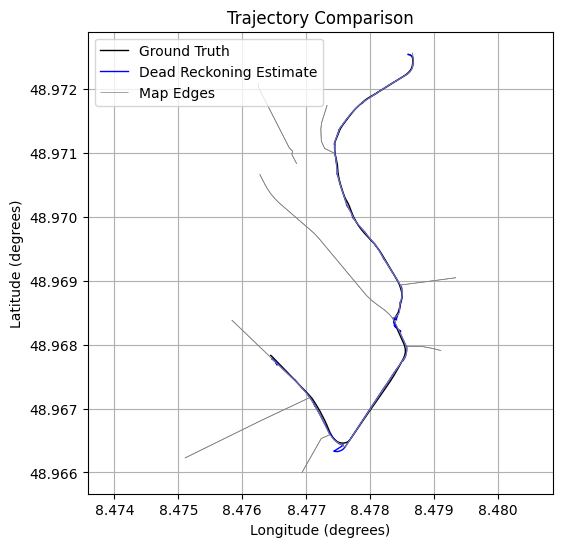

In [7]:
seq = "10"
seq10_data = get_kitti_data(seq, root_dir, is_sync=False)
result_seq10 = run_dead_reckoning_100Hz(seq10_data)
visualize_trajectories(result_seq10["lla_estimated"], result_seq10["lla_ground_truth"], result_seq10["local_edges"])

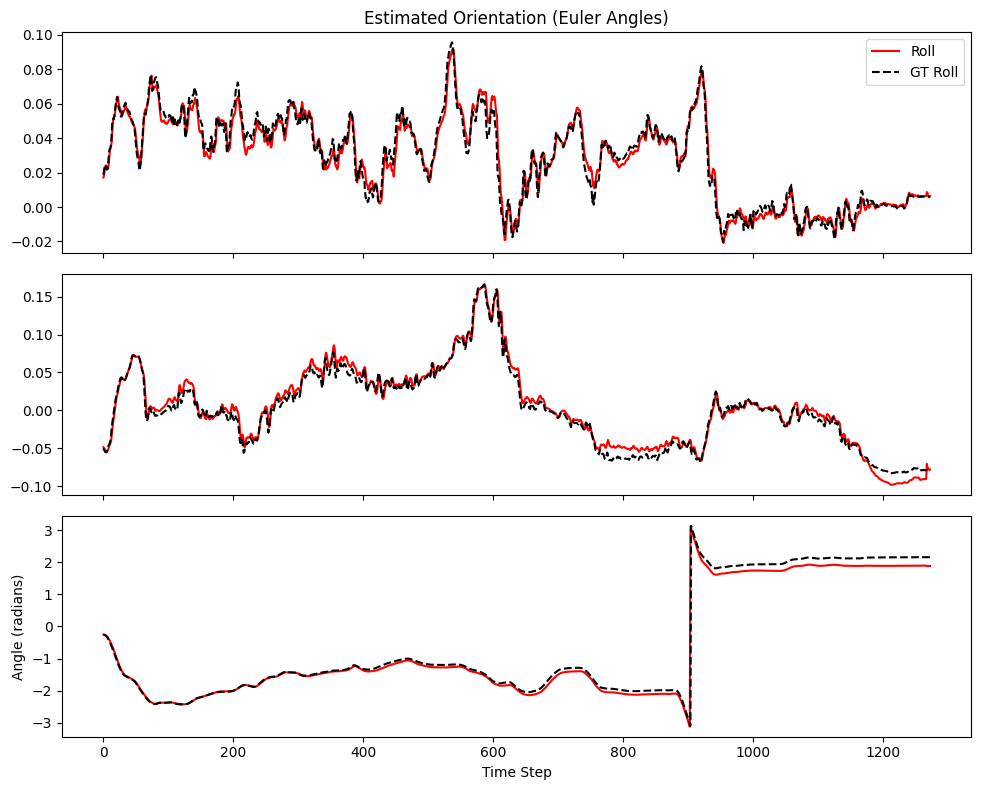

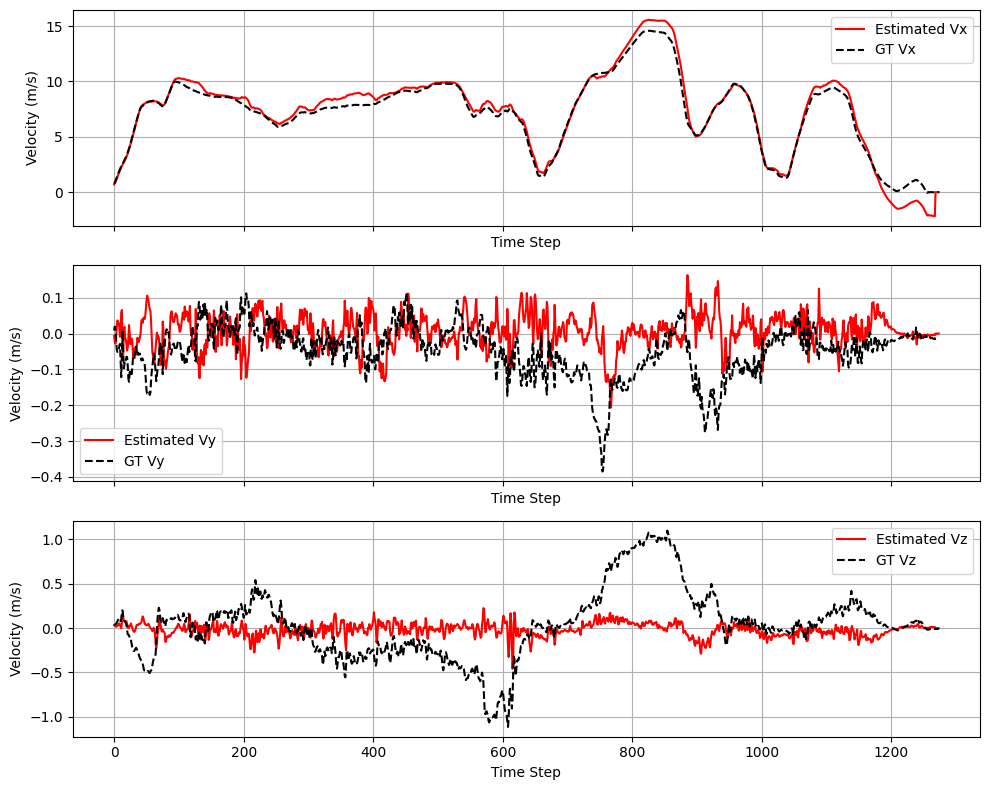

In [8]:
visualize_orientation(result_seq10)
visualize_velocity_in_body_frame(result_seq10, seq10_data)

## Save the results

In [9]:
seq09_result_dir = os.path.join(result_dir, "09", "map_aided_ml_enhanced_dead_reckoning.npz")
seq10_result_dir = os.path.join(result_dir, "10", "map_aided_ml_enhanced_dead_reckoning.npz")

np.savez(seq09_result_dir, **result_seq09)
np.savez(seq10_result_dir, **result_seq10)